In [1]:
import pandas as pd
import csv

In [2]:
df = pd.read_csv(r"D:\AIO2026\data_projectConquest\prject1\archive\NetFlix.csv", encoding='UTF-8')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\AIO2026\\data_projectConquest\\prject1\\archive\\NetFlix.csv'

In [3]:
df.shape # dong, cot

(7787, 12)

In [4]:
for col in df.columns:
    print(col)

show_id
type
title
director
cast
country
date_added
release_year
rating
duration
genres
description


In [5]:
temp = 0
for col in df.columns:
    for i in range(df.shape[0]):
        if pd.isna(df.iloc[i][col]):
            temp+=1
    print(f"{col} : {temp}")
    temp = 0

show_id : 0
type : 0
title : 0
director : 2389
cast : 718
country : 507
date_added : 10
release_year : 0
rating : 7
duration : 0
genres : 0
description : 0


In [6]:
df = df.dropna(subset=['rating', 'date_added'])
df['country'] = df['country'].fillna('unknown')
df = df.drop(columns=['director', 'cast'])
df.to_csv(r'D:\AIO2026\data_projectConquest\prject1\netflix_cleaned.csv', index=False)

In [110]:
df = pd.read_csv(r'D:\AIO2026\data_projectConquest\prject1\netflix_cleaned.csv', encoding='UTF-8')
df_original = df.copy()
df.head()

,show_id,type,title,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [99]:
temp = 0
for col in df.columns:
    for i in range(df.shape[0]):
        if pd.isna(df.iloc[i][col]):
            temp+=1
    print(f'{col} : {temp}')

show_id : 0
type : 0
title : 0
country : 0
date_added : 0
release_year : 0
rating : 0
duration : 0
genres : 0
description : 0


In [10]:
#release_year

In [100]:


movies_years = df['release_year'].value_counts().sort_index()
print(movies_years)


release_year
1925       1
1942       2
1943       3
1944       3
1945       3
        ... 
2017    1010
2018    1120
2019     996
2020     868
2021      31
Name: count, Length: 73, dtype: int64


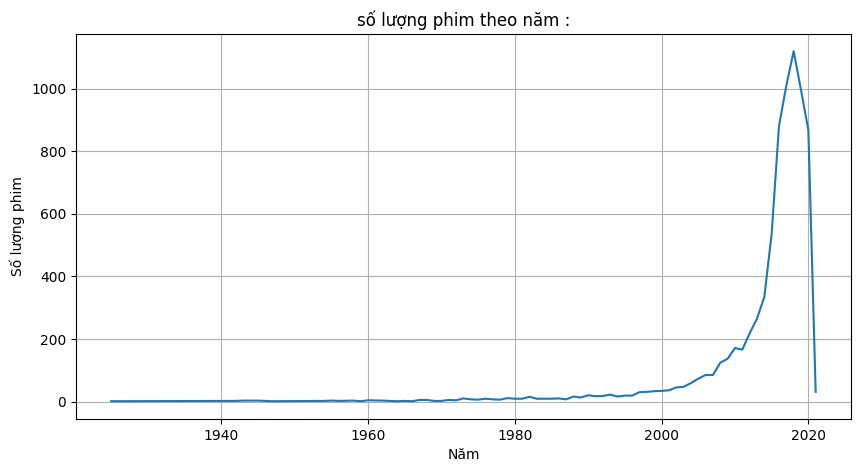

In [102]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.grid()
plt.plot(movies_years.index, movies_years.values)
plt.title("số lượng phim theo năm :")
plt.xlabel("Năm")
plt.ylabel("Số lượng phim")
plt.show()

In [ ]:
# Dựa trên biểu đồ, số lượng phim tăng mạnh từ sau năm 2000 và đạt đỉnh vào năm 2018 với khoảng 1120 phim.
#  Sau đó, số lượng phim có xu hướng giảm trong giai đoạn 2019–2020, có thể do ảnh hưởng của đại dịch COVID-19.
#  Ngoài ra, dữ liệu năm 2021 giảm mạnh có thể do chưa được cập nhật đầy đủ

In [51]:
#Thể loại phim

In [103]:
df['genres'].head()

0    International TV Shows, TV Dramas, TV Sci-Fi &...
1       Horror Movies, International Movies, Thrillers
2          Dramas, International Movies, Sports Movies
3                                             Comedies
4    British TV Shows, Docuseries, Science & Nature TV
Name: genres, dtype: str

In [104]:
df["genres"] = df['genres'].str.split(",")

In [105]:
df = df.explode("genres")
df["genres"].head

<bound method NDFrame.head of 0       International TV Shows
0                    TV Dramas
0          TV Sci-Fi & Fantasy
1                Horror Movies
1         International Movies
                 ...          
7768                    Dramas
7768        Independent Movies
7769                    Dramas
7769        Independent Movies
7769           Romantic Movies
Name: genres, Length: 17042, dtype: str>

In [106]:
df["genres"].value_counts().head(10)

genres
 International Movies     2323
Dramas                    1383
Comedies                  1074
Documentaries              751
 Dramas                    722
Action & Adventure         721
International TV Shows     689
 Independent Movies        653
 TV Dramas                 641
 Romantic Movies           528
Name: count, dtype: int64

In [107]:
df['genres'] = df['genres'].str.strip()
top_genres = df['genres'].value_counts().head(10)
print(top_genres)

genres
International Movies        2437
Dramas                      2105
Comedies                    1471
International TV Shows      1197
Documentaries                786
Action & Adventure           721
TV Dramas                    703
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64


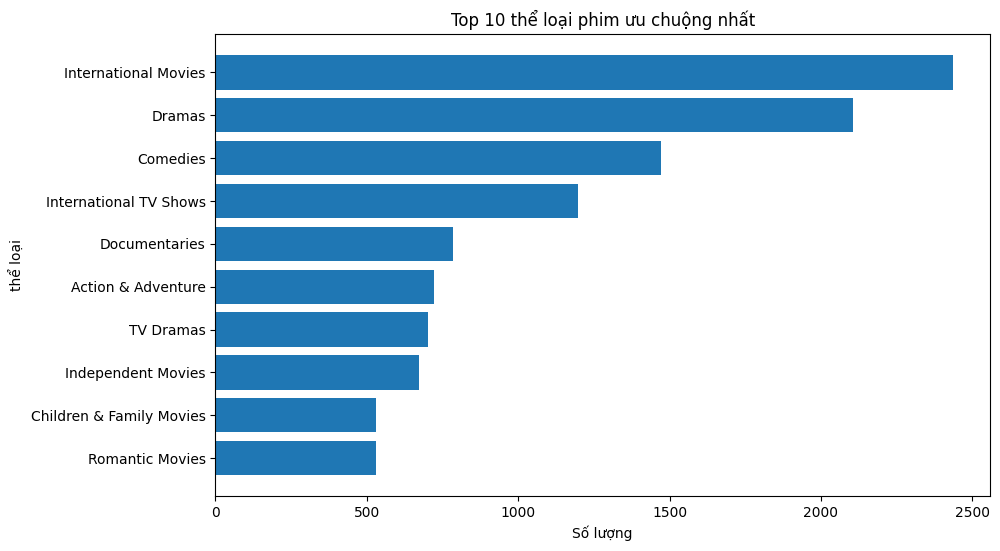

In [108]:
plt.figure(figsize=(10,6))
plt.barh(top_genres.index, top_genres.values)
plt.title('Top 10 thể loại phim ưu chuộng nhất')
plt.xlabel("Số lượng")
plt.ylabel("thể loại")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#thể loại internatinal là phổ biến nhất, bám sát ngay sau đó là dòng phim dramas và conmedies cho thấy 
# nền tảng đang đầu tư nhiều vào phim tâm lí và hài

### Country

In [112]:
df_country = df_original.copy()

In [113]:
df_country['country'] = df_country['country'].str.split(", ")
df_country = df_country.explode('country')
df_country['country']


0               Brazil
1                India
2            Indonesia
3        United States
4       United Kingdom
             ...      
7767            France
7767           Belgium
7767             Spain
7768     United States
7769     United States
Name: country, Length: 9553, dtype: str

In [116]:
df_country['country'] = df_country['country'].str.strip()
top_country = df_country['country'].value_counts().head(10)
print(top_country)

country
United States     3287
India              990
United Kingdom     721
unknown            505
Canada             412
France             349
Japan              285
Spain              215
South Korea        212
Germany            199
Name: count, dtype: int64


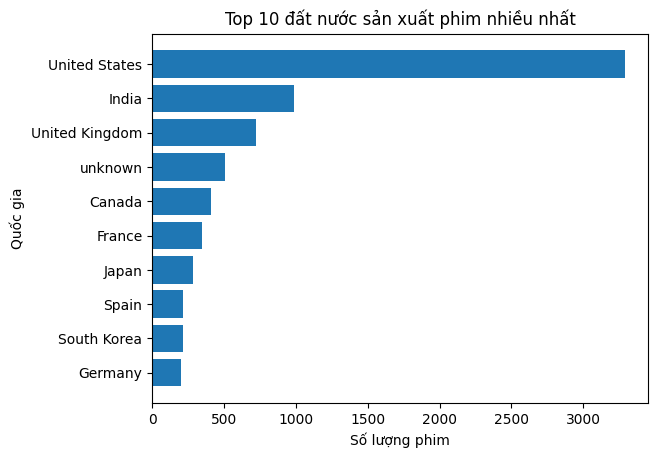

In [117]:
plt.Figure(figsize=(10,6))
plt.barh(top_country.index, top_country.values)
plt.title("Top 10 đất nước sản xuất phim nhiều nhất")
plt.xlabel("Số lượng phim")
plt.ylabel("Quốc gia")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#Dựa vào biểu đồ có thể thấy United States chiếm số lượng phim áp đảo so với các nước khác với số lượng phim > 3000 phim
#Trong khi đó chiếm vị trí thứ 2 là India với chỉ hơn 1000 phim bằng 1/3 so với hạng 1
#Bên cạnh đó các nước như United. Canada, France cũng đóng góp một lượng phim đáng kể
#Tuy nhiên vẫn còn một số lượng không nhỏ các phim bị mất dữ liệu

### Rating

In [119]:
df_rating = df_original.copy()
df_rating['rating'].head

<bound method NDFrame.head of 0       TV-MA
1       TV-MA
2       TV-PG
3           R
4        TV-G
        ...  
7765    TV-14
7766    TV-MA
7767    NC-17
7768    PG-13
7769    TV-MA
Name: rating, Length: 7770, dtype: str>

rating
TV-MA       2861
TV-14       1928
TV-PG        804
R            665
PG-13        386
TV-Y         279
TV-Y7        270
PG           247
TV-G         194
NR            83
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64


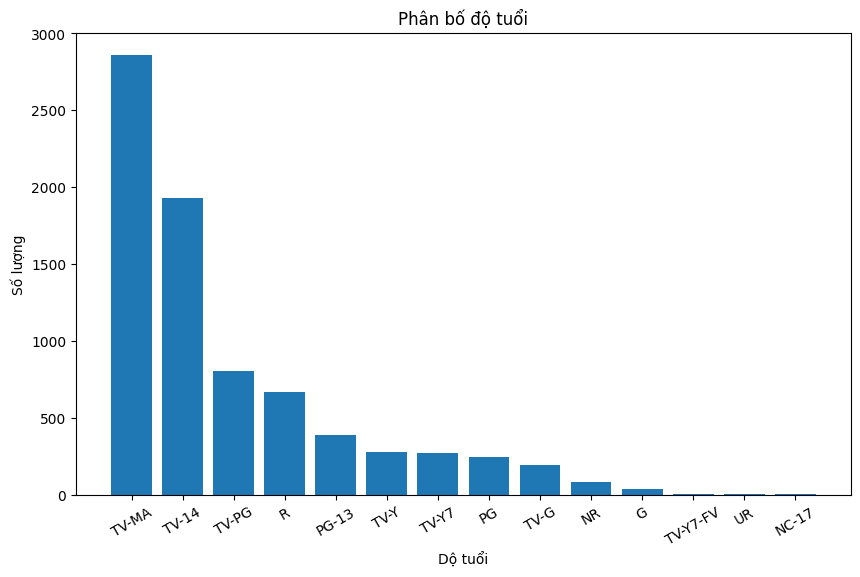

In [122]:
top_rating = df['rating'].value_counts()
print(top_rating)
plt.figure(figsize=(10,6))
plt.bar(top_rating.index, top_rating.values)
plt.title("Phân bố độ tuổi")
plt.xlabel("Dộ tuổi")
plt.ylabel("Số lượng")
plt.xticks(rotation = 30)
plt.show()

In [ ]:
#Kết quả cho thấy các nội dung dành cho người trưởng thành (TV-MA) chiếm tỷ lệ cao nhất, tiếp theo là nhóm đối tượng thanh thiếu niên (TV-14). Trong khi đó,
#nội dung dành cho trẻ em và gia đình chiếm tỷ lệ thấp hơn, 
# cho thấy nền tảng tập trung chủ yếu vào đối tượng người xem trưởng thành